In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from transformers import AutoModelForCausalLM, AttentionInterface
from transformers.modeling_utils import ALL_ATTENTION_FUNCTIONS
from transformers.models.llama.modeling_llama import eager_attention_forward
import torch
from typing import Optional

from datasets import load_dataset
import numpy as np
import random
import time
from torch.profiler import profile, ProfilerActivity, record_function
import warnings
warnings.filterwarnings("ignore")

def set_all_seeds(seed=42):
    """Set all random seeds for reproducible results."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

CAPTURED_QKV = []
def eager_capture(
    module: torch.nn.Module,
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    *args,
    **kwargs,
) -> tuple[torch.Tensor, Optional[torch.Tensor]]:
    CAPTURED_QKV.append((query.cpu(), key.cpu(), value.cpu()))
    return ALL_ATTENTION_FUNCTIONS["flash_attention_3"](module, query, key, value, *args, **kwargs)

AttentionInterface.register("eager_capture", eager_capture)


def load_model_and_tokenizer():
    model_name = "meta-llama/Meta-Llama-3-8B-Instruct"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation='eager_capture',
    )

    return model, tokenizer

def prepare_conversational_data(tokenizer, num_samples, max_length):
    print(f"Loading conversational dataset...")

    # Load OpenAssistant Conversations dataset
    dataset = load_dataset("OpenAssistant/oasst1", split="train")

    # Filter for English conversations and get human messages
    conversations = []
    for item in dataset:
        if item["lang"] == "en" and item["role"] == "prompter":
            text = item["text"].strip()
            if len(text) > 4000 and len(text) < 8000:  # Filter reasonable length
                conversations.append(text)

    # Take first num_samples and ensure we have enough
    if len(conversations) < num_samples:
        # Repeat conversations if needed
        conversations = (conversations * ((num_samples // len(conversations)) + 1))[:num_samples]
    else:
        conversations = conversations[:num_samples]

    print(f"Preparing {len(conversations)} conversations...")

    # Tokenize all conversations
    tokenized = tokenizer(
        conversations,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    ).to('cuda')

    return tokenized

/data/users/mhoehnerbach/branches/flex-skip-corr/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/users/mhoehnerbach/branches/flex-skip-corr/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.sparse import csr_matrix, issparse


In [2]:
set_all_seeds(42)

model, tokenizer = load_model_and_tokenizer()
inputs = prepare_conversational_data(tokenizer, num_samples=6, max_length=4096)
output = model(**inputs)

Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.29it/s]


Loading conversational dataset...
Preparing 6 conversations...


In [3]:
import matplotlib.pyplot as plt

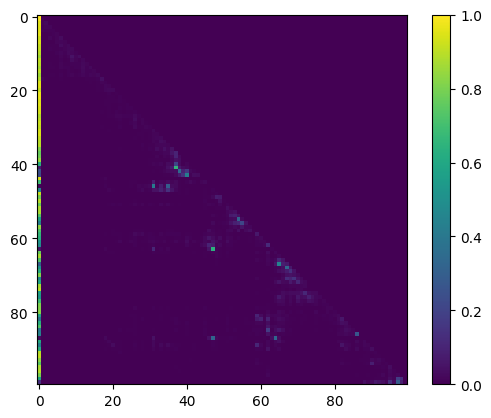

In [67]:
import math

def attn(b, l, h):
    q = CAPTURED_QKV[l][0][b,h,:,:]
    k = CAPTURED_QKV[l][1][b,h // (CAPTURED_QKV[0][0].shape[1] // CAPTURED_QKV[0][1].shape[1]),:,:]
    scores = q.detach() @ k.detach().T
    return scores / math.sqrt(128) + torch.triu(torch.full_like(scores, float('-inf')), diagonal=1)
    
plt.imshow(torch.softmax(attn(0, 20, 21), -1)[:100,:100])
plt.colorbar()

In [69]:
torch.save(CAPTURED_QKV, "captured_qkv.pt")

In [70]:
! ls -lh

total 3.1G
-rw-r--r-- 1 mhoehnerbach users   63 Aug 25 15:24 AGENTS.md
drwxr-xr-x 1 mhoehnerbach users  308 Aug 25 15:24 android
drwxr-xr-x 1 mhoehnerbach users   54 Aug 25 15:24 aten
-rw-r--r-- 1 mhoehnerbach users 2.8K Aug 25 15:24 aten.bzl
drwxr-xr-x 1 mhoehnerbach users  688 Aug 25 15:24 benchmarks
-rw-r--r-- 1 mhoehnerbach users 7.3K Aug 26 17:31 bench.py
drwxr-xr-x 1 mhoehnerbach users  542 Aug 25 15:24 binaries
-rw-r--r-- 1 mhoehnerbach users  85K Aug 25 15:24 buckbuild.bzl
-rw-r--r-- 1 mhoehnerbach users 4.1K Aug 25 15:24 BUCK.oss
drwxr-xr-x 1 mhoehnerbach users  960 Aug 26 17:42 build
-rw-r--r-- 1 mhoehnerbach users  29K Aug 25 15:24 BUILD.bazel
-rw-r--r-- 1 mhoehnerbach users  12K Aug 25 15:24 build.bzl
-rw-r--r-- 1 mhoehnerbach users  73K Aug 25 15:24 build_variables.bzl
drwxr-xr-x 1 mhoehnerbach users  216 Aug 25 15:24 c10
drwxr-xr-x 1 mhoehnerbach users  192 Aug 25 15:24 caffe2
-rw-r--r-- 1 mhoehnerbach users 3.1G Aug 27 10:57 captured_qkv.pt
-rw-r--r-- 1 mhoehnerbach user

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
